# News Sentiment by Asset

Two questions, one dataset (`data/output/news_sentiment.parquet`, the Tyche pipeline output):

1. **Over time** — how has each asset's news sentiment moved month to month?
2. **Distribution** — how do the assets' sentiment distributions compare to one another?

Rows are one `(article, ticker)` each. Assets are grouped by **`name`** (14 clean
companies) rather than the raw `ticker`, which carries parsing-artifact variants
(`NASDAQ:AAPL`, `AAPL`, `NASDAQ:NASDAQ:AAPL` -> all the asset `AAPL`).

**Two sentiment metrics** are available; switch with `METRIC` in the config cell:

- `raw_score` — the LLM sentiment `p_pos - p_neg`, in `[-1, 1]`. Directly
  interpretable: `> 0` net-positive coverage, `< 0` net-negative.
- `sentiment_final` — the Neutralizer's entity-debiased, cross-sectionally
  z-scored signal (mean ~ 0, std ~ 1). Better for *relative* comparison; not an
  absolute polarity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Palette (validated, colorblind-safe)
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SOFT = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
BLUE = "#2a78d6"  # positive pole
RED = "#d03b3b"  # negative pole
GRAY_MID = "#f0efec"  # diverging midpoint

# Diverging map: negative -> red, neutral -> gray, positive -> blue.
DIVERGING = LinearSegmentedColormap.from_list("sent", [RED, GRAY_MID, BLUE])

# Recessive, chartjunk-free matplotlib style
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 10,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_SOFT,
        "ytick.labelcolor": INK_SOFT,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def divergent_colors(values, vmax=None):
    # Map signed values to diverging colors centered at 0.
    values = np.asarray(values, dtype=float)
    vmax = vmax or (np.nanmax(np.abs(values)) or 1.0)
    return DIVERGING(0.5 + 0.5 * np.clip(values / vmax, -1, 1))

In [2]:
# Config
from pathlib import Path


def _find(rel):
    # Resolve a repo-relative path whether the kernel runs from the repo root or
    # from notebooks/ — walk up until the file is found.
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / rel
        if p.exists():
            return str(p)
    return rel  # fall through; pandas will raise a clear error if truly missing


DATA_PATH = _find("data/output/news_sentiment.parquet")
ASSET_COL = "name"  # group assets by cleaned company name
METRIC = "raw_score"  # "raw_score"  or  "sentiment_final"
REPRESENTATIVES_ONLY = True  # one row per dedup cluster (drop reprints)

METRIC_LABEL = {
    "raw_score": "Raw sentiment  (p_pos - p_neg)",
    "sentiment_final": "Neutralized sentiment  (z-score)",
}[METRIC]

In [3]:
# Load & clean
cols = [ASSET_COL, "valid_time", "raw_score", "sentiment_final", "is_representative"]
df = pd.read_parquet(DATA_PATH, columns=cols)

if REPRESENTATIVES_ONLY and "is_representative" in df.columns:
    df = df[df["is_representative"]]

df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True)
df = df.dropna(subset=[ASSET_COL, "valid_time", METRIC])
df["month"] = df["valid_time"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Fixed asset order (by overall mean of the chosen metric, high -> low) so every
# chart paints assets in the same order.
ASSET_ORDER = (
    df.groupby(ASSET_COL)[METRIC].mean().sort_values(ascending=False).index.tolist()
)
print(
    f"{len(df):,} rows | {len(ASSET_ORDER)} assets | "
    f"{df['valid_time'].min().date()} -> {df['valid_time'].max().date()}"
)
print("representatives_only =", REPRESENTATIVES_ONLY, "| metric =", METRIC)

343,977 rows | 14 assets | 2023-10-01 -> 2025-07-23
representatives_only = True | metric = raw_score


In [4]:
# Per-asset summary table
g = df.groupby(ASSET_COL)[METRIC]
summary = pd.DataFrame(
    {
        "articles": g.size(),
        "mean": g.mean(),
        "median": g.median(),
        "std": g.std(),
        "pct_positive": df.assign(pos=df[METRIC] > 0).groupby(ASSET_COL)["pos"].mean()
        * 100,
    }
).reindex(ASSET_ORDER)

_m = summary["mean"].abs().max()
summary.style.format(
    {
        "articles": "{:,.0f}",
        "mean": "{:+.3f}",
        "median": "{:+.3f}",
        "std": "{:.3f}",
        "pct_positive": "{:.0f}%",
    }
).background_gradient(subset=["mean"], cmap=DIVERGING, vmin=-_m, vmax=_m)

,articles,mean,median,std,pct_positive
name,,,,,
AVGO,"14,953",+0.319,+0.500,0.431,77%
AMZN,"24,782",+0.291,+0.500,0.436,75%
ORCL,"9,893",+0.287,+0.500,0.452,73%
LLY,"25,373",+0.267,+0.500,0.484,71%
NVDA,"47,475",+0.266,+0.500,0.472,71%
V,"13,746",+0.265,+0.500,0.457,75%
MSFT,"32,553",+0.243,+0.500,0.477,71%
GOOG,"19,448",+0.206,+0.400,0.476,68%
WMT,"17,904",+0.175,+0.300,0.489,66%


## 1 - Ranked mean sentiment

The headline comparison: each asset's average sentiment, sorted. Bars are colored
by polarity (blue = net-positive, red = net-negative) and directly labeled — no
legend needed.

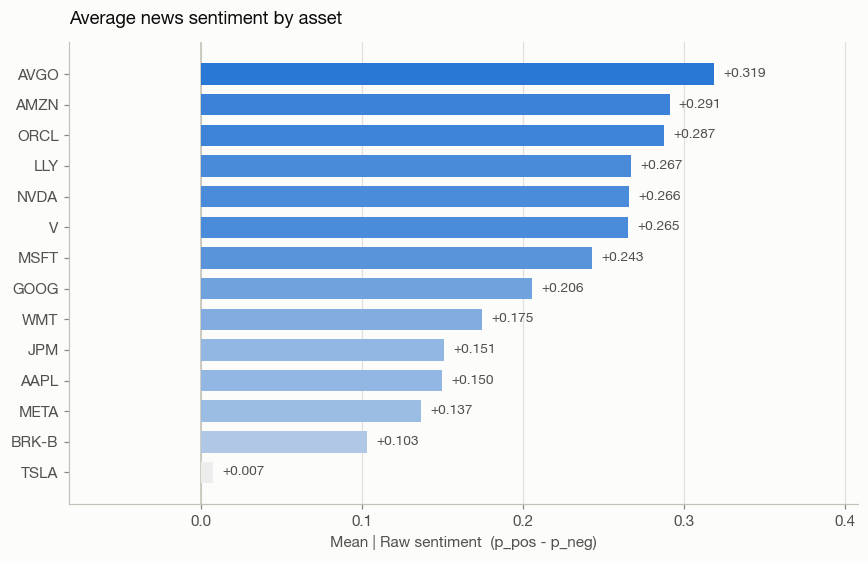

In [5]:
means = summary["mean"].reindex(ASSET_ORDER[::-1])  # low at bottom -> high at top
fig, ax = plt.subplots(figsize=(8, 5.2))

ax.barh(
    means.index,
    means.values,
    color=divergent_colors(means.values),
    height=0.7,
    zorder=3,
)
ax.axvline(0, color=BASELINE, lw=1)

for nm, v in means.items():
    ax.annotate(
        f"{v:+.3f}",
        (v, nm),
        xytext=(6 if v >= 0 else -6, 0),
        textcoords="offset points",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
        color=INK_SOFT,
    )

pad = means.abs().max() * 0.28
ax.set_xlim(means.min() - pad, means.max() + pad)
ax.set_xlabel(f"Mean | {METRIC_LABEL}")
ax.set_title("Average news sentiment by asset", fontweight="bold", loc="left", pad=12)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 2 - Sentiment over time: all assets at a glance

A month x asset heatmap. Rows are assets (same order as above), columns are
months; color is that month's mean sentiment (blue positive, red negative,
centered at 0). The most compact way to compare *every* asset's trajectory at
once — scan a row for one asset over time, a column for cross-asset mood in a
given month.

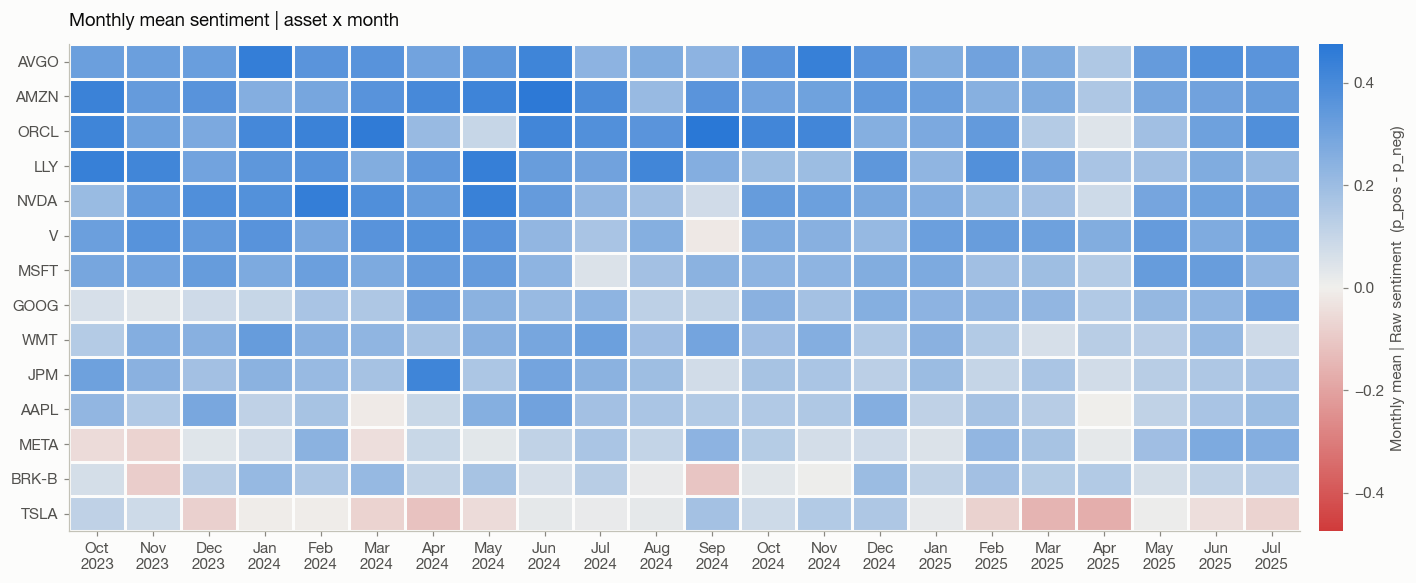

In [6]:
pivot = (
    df.groupby([ASSET_COL, "month"])[METRIC]
    .mean()
    .unstack("month")
    .reindex(ASSET_ORDER)
)

vmax = np.nanmax(np.abs(pivot.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(13, 5.4))
im = ax.imshow(pivot.values, aspect="auto", cmap=DIVERGING, norm=norm)

ax.set_yticks(range(len(pivot.index)), pivot.index)
months = pivot.columns
step = max(1, len(months) // 12)
ax.set_xticks(
    range(0, len(months), step), [m.strftime("%b\n%Y") for m in months[::step]]
)
ax.set_xticks(np.arange(-0.5, len(months), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)  # 2px surface gap between cells
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.025)
cbar.set_label(f"Monthly mean | {METRIC_LABEL}", color=INK_SOFT)
cbar.outline.set_visible(False)
ax.set_title(
    "Monthly mean sentiment | asset x month", fontweight="bold", loc="left", pad=12
)
fig.tight_layout()
plt.show()

## 3 - Sentiment over time: per-asset trend

Small multiples: one panel per asset, sharing a y-axis so heights are comparable.
Each panel plots the monthly mean (blue) with a shaded +/-1 sigma band and a zero
reference line. Panels are ordered by overall mean (top-left highest).

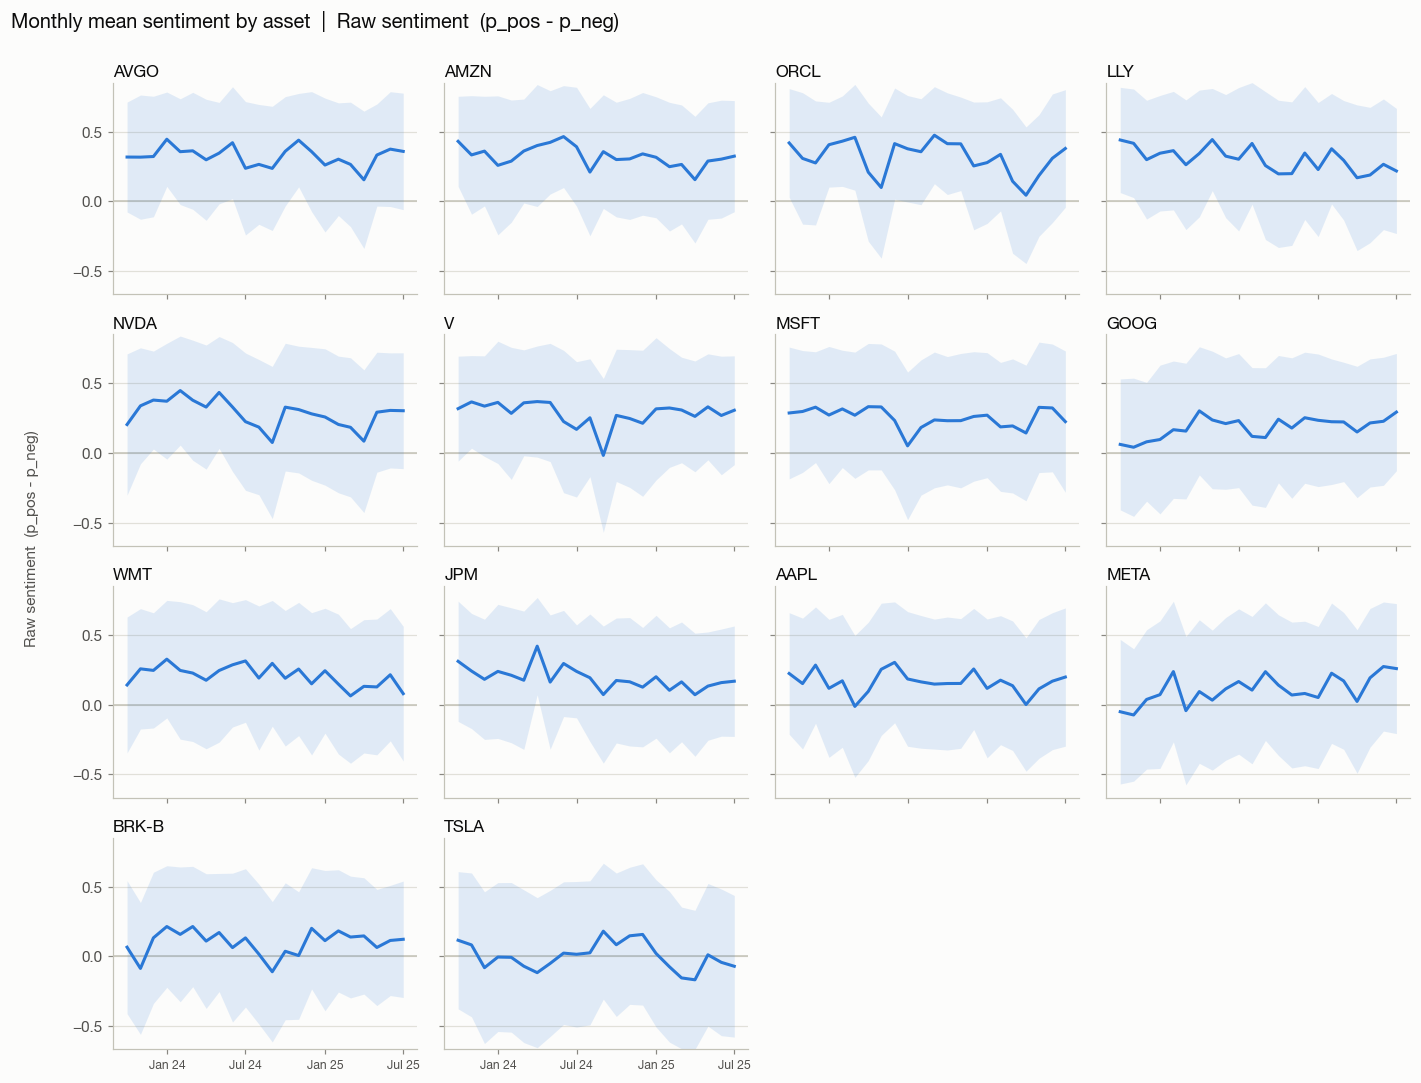

In [7]:
import matplotlib.dates as mdates

mstats = df.groupby([ASSET_COL, "month"])[METRIC].agg(["mean", "std"]).reset_index()

ncols = 4
nrows = int(np.ceil(len(ASSET_ORDER) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(13, 2.5 * nrows), sharex=True, sharey=True
)
axes = axes.ravel()

ylo = (mstats["mean"] - mstats["std"].fillna(0)).min()
yhi = (mstats["mean"] + mstats["std"].fillna(0)).max()

for ax, nm in zip(axes, ASSET_ORDER):
    d = mstats[mstats[ASSET_COL] == nm].sort_values("month")
    lo, hi = d["mean"] - d["std"].fillna(0), d["mean"] + d["std"].fillna(0)
    ax.axhline(0, color=BASELINE, lw=1, zorder=1)
    ax.fill_between(d["month"], lo, hi, color=BLUE, alpha=0.13, lw=0, zorder=2)
    ax.plot(d["month"], d["mean"], color=BLUE, lw=2, zorder=3)
    ax.set_title(nm, fontsize=11, fontweight="bold", loc="left", pad=4)
    ax.margins(x=0.02)
    ax.grid(axis="x", visible=False)

for ax in axes[len(ASSET_ORDER) :]:
    ax.set_visible(False)

ax.set_ylim(ylo, yhi)
# Sparse, non-colliding date ticks (Jan & Jul each year), shared across panels.
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
for ax in axes[: len(ASSET_ORDER)]:
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0)
        lbl.set_fontsize(8)
fig.suptitle(
    f"Monthly mean sentiment by asset  |  {METRIC_LABEL}",
    x=0.01,
    ha="left",
    fontweight="bold",
    fontsize=13,
)
fig.supylabel(METRIC_LABEL, color=INK_SOFT, fontsize=10)
fig.tight_layout(rect=(0.02, 0, 1, 0.98))
plt.show()

## 4 - Distribution comparison

How *spread out* is each asset's sentiment, not just its average? Horizontal
violins show the full shape of each asset's per-article distribution; the white
dot marks the median, the thick bar the interquartile range. Ordered by median,
colored by median polarity. The dashed line is zero (neutral).

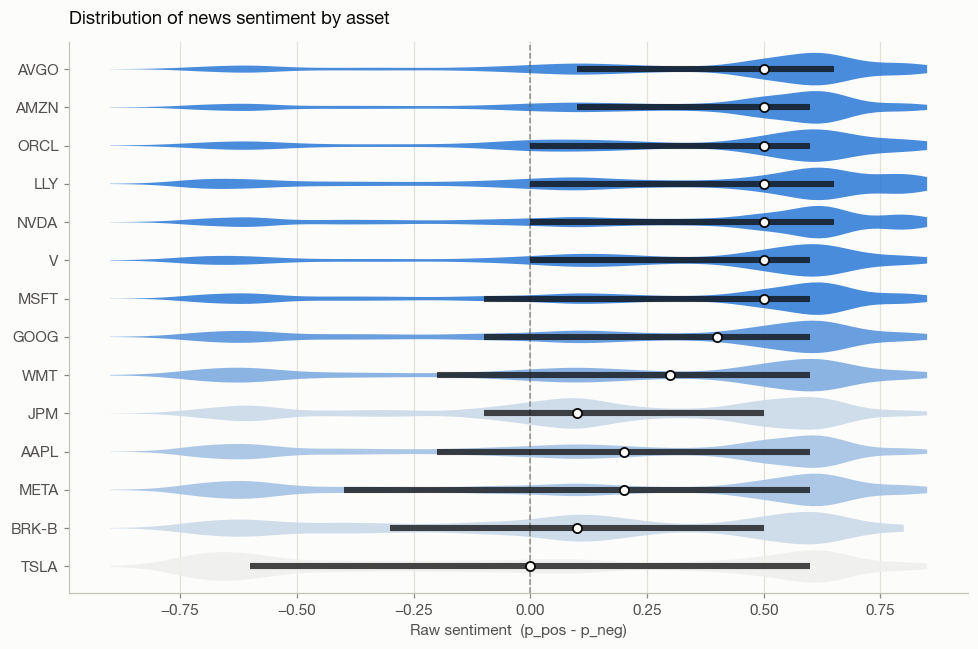

In [8]:
order_lo_hi = ASSET_ORDER[::-1]  # highest near the top
data = [df.loc[df[ASSET_COL] == n, METRIC].values for n in order_lo_hi]
medians = np.array([np.median(x) for x in data])

fig, ax = plt.subplots(figsize=(9, 6))
positions = np.arange(len(order_lo_hi))
vmax = np.abs(medians).max()

parts = ax.violinplot(
    data, positions=positions, vert=False, widths=0.85, showextrema=False
)
for body, m in zip(parts["bodies"], medians):
    body.set_facecolor(divergent_colors([m], vmax=vmax)[0])
    body.set_edgecolor("none")
    body.set_alpha(0.85)

for pos, x in zip(positions, data):
    q1, q3 = np.percentile(x, [25, 75])
    ax.hlines(pos, q1, q3, color=INK, lw=4, zorder=4, alpha=0.75)
    ax.plot(np.median(x), pos, "o", color=SURFACE, mec=INK, mew=1.2, ms=6, zorder=5)

ax.axvline(0, color=INK_SOFT, lw=1, ls="--", alpha=0.6, zorder=2)
ax.set_yticks(positions, order_lo_hi)
ax.set_xlabel(METRIC_LABEL)
ax.set_ylim(-0.7, len(order_lo_hi) - 0.3)
ax.set_title(
    "Distribution of news sentiment by asset", fontweight="bold", loc="left", pad=12
)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

---
### Notes

- **Switch metric or scope** in the config cell: set `METRIC = "sentiment_final"`
  for the neutralized signal, or `REPRESENTATIVES_ONLY = False` to include every
  reprint (reprints share a cluster's score, so keeping them re-weights heavily
  syndicated stories).
- Diverging color is centered at **0** (absolute polarity). With `raw_score`, most
  assets skew net-positive — that is real; the *ranking* is what separates them.
- The `+/-1 sigma` band in the small multiples is dispersion of individual-article
  scores within the month, not a confidence interval on the mean.